In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import os
from PIL import Image

In [3]:
# Load bounding box data for train, val, and test splits and combine into one dataframe

train_bbox_df = pd.read_csv('/Users/shreyasgotur/Downloads/deepfashion_anno/Category and Attribute Prediction Benchmark/Anno_fine/train_bbox.txt', sep=r"\s+", skiprows=1, header=0, names=["x1", "y1", "x2", "y2"])
val_bbox_df   = pd.read_csv('/Users/shreyasgotur/Downloads/deepfashion_anno/Category and Attribute Prediction Benchmark/Anno_fine/val_bbox.txt',   sep=r"\s+", skiprows=1, header=0, names=["x1", "y1", "x2", "y2"])
test_bbox_df  = pd.read_csv('/Users/shreyasgotur/Downloads/deepfashion_anno/Category and Attribute Prediction Benchmark/Anno_fine/test_bbox.txt',  sep=r"\s+", skiprows=1, header=0, names=["x1", "y1", "x2", "y2"])

train_imgs = pd.read_csv('/Users/shreyasgotur/Downloads/deepfashion_anno/Category and Attribute Prediction Benchmark/Anno_fine/train.txt', sep=r"\s+", skiprows=1, header=0, names=["img_name"])
val_imgs   = pd.read_csv('/Users/shreyasgotur/Downloads/deepfashion_anno/Category and Attribute Prediction Benchmark/Anno_fine/val.txt',   sep=r"\s+", skiprows=1, header=0, names=["img_name"])
test_imgs  = pd.read_csv('/Users/shreyasgotur/Downloads/deepfashion_anno/Category and Attribute Prediction Benchmark/Anno_fine/test.txt',  sep=r"\s+", skiprows=1, header=0, names=["img_name"])

train_bbox_df.insert(0, "img_name", train_imgs["img_name"])
val_bbox_df.insert(0, "img_name", val_imgs["img_name"])
test_bbox_df.insert(0, "img_name", test_imgs["img_name"])

bbox_df = pd.concat([train_bbox_df, val_bbox_df, test_bbox_df], ignore_index=True)

bbox_df["width"]  = bbox_df["x2"] - bbox_df["x1"]
bbox_df["height"] = bbox_df["y2"] - bbox_df["y1"]
bbox_df["area"]   = bbox_df["width"] * bbox_df["height"]

bbox_df.head()

,img_name,x1,y1,x2,y2,width,height,area
0,img/Strapless_Diamond_Print_Dress/img_00000038...,75,43,176,300,101,257,25957
1,img/Mid-Rise_-_Acid_Wash_Skinny_Jeans/img_0000...,64,1,129,273,65,272,17680
2,img/Zippered_Single-Button_Blazer/img_00000078...,1,12,257,300,256,288,73728
3,img/Abstract_Chevron_Draped_Dress/img_00000013...,24,54,148,300,124,246,30504
4,img/Boho_Babe_Crochet_Top/img_00000047.jpg,50,86,150,249,100,163,16300


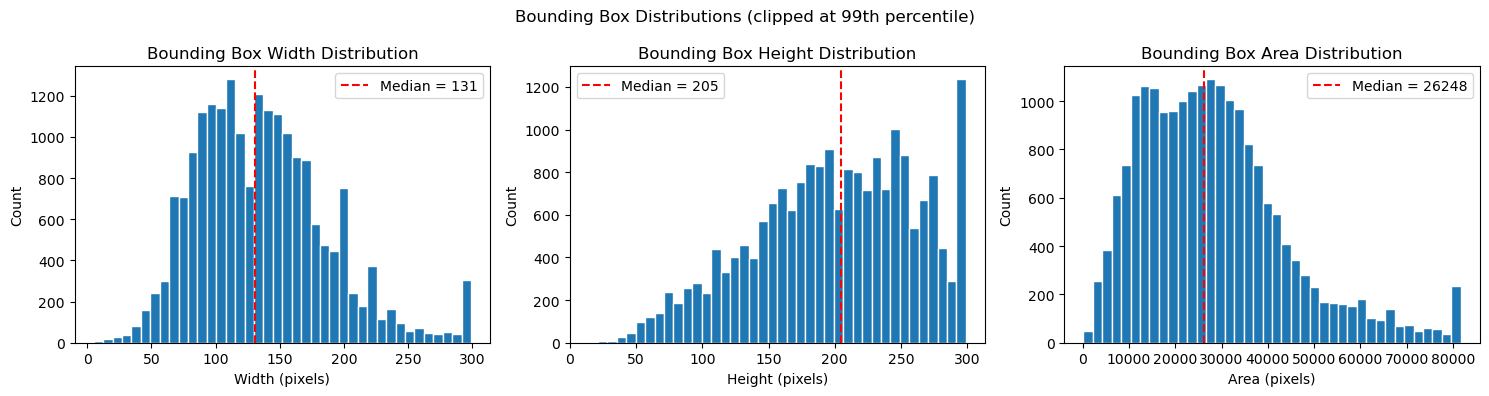

         width   height     area
count  19994.0  19994.0  19994.0
mean     135.8    199.7  28317.5
std       51.6     61.3  16133.7
min        5.0     14.0    180.0
25%       96.0    157.0  16128.0
50%      131.0    205.0  26248.0
75%      166.0    248.0  36475.8
max      299.0    299.0  89401.0


In [4]:
# Distribution of bounding box width, height, and area across all images

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["width", "height", "area"]):
    clipped = bbox_df[col].clip(upper=bbox_df[col].quantile(0.99))
    ax.hist(clipped, bins=40, edgecolor="white")
    ax.axvline(bbox_df[col].median(), color="red", linestyle="--",
               label="Median = {:.0f}".format(bbox_df[col].median()))
    ax.set_title("Bounding Box {} Distribution".format(col.title()))
    ax.set_xlabel("{} (pixels)".format(col.title()))
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Bounding Box Distributions (clipped at 99th percentile)")
plt.tight_layout()
plt.show()

print(bbox_df[["width", "height", "area"]].describe().round(1))

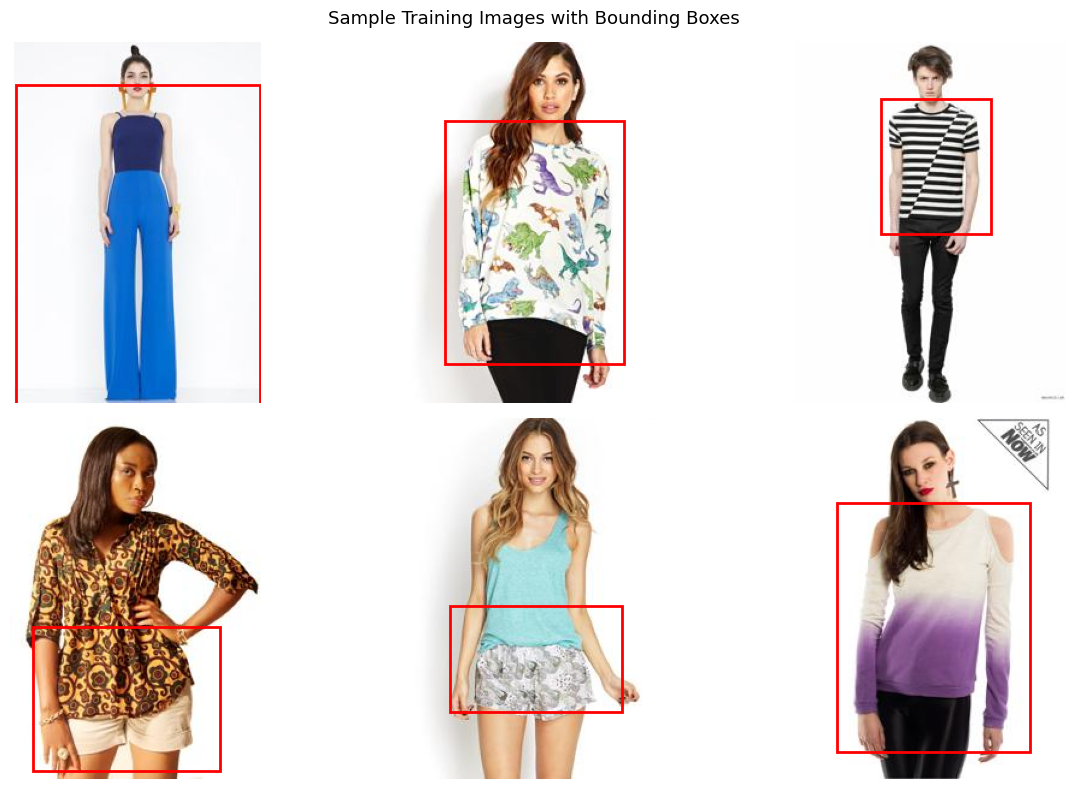

In [12]:
# Sample training images with bounding boxes overlaid to show how garments are framed

IMG_DIR = "/Users/shreyasgotur/Downloads/deepfashion_imgs"
sample = train_bbox_df.sample(6, random_state=7).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, row in sample.iterrows():
    full_path = os.path.join(IMG_DIR, row["img_name"])
    try:
        img = Image.open(full_path).convert("RGB")
        axes[i].imshow(img)
        rect = patches.Rectangle(
            (row["x1"], row["y1"]),
            row["x2"] - row["x1"],
            row["y2"] - row["y1"],
            linewidth=2, edgecolor="red", facecolor="none"
        )
        axes[i].add_patch(rect)
    except FileNotFoundError:
        axes[i].text(0.5, 0.5, "Image not found", ha="center", va="center")
    axes[i].axis("off")

plt.suptitle("Sample Training Images with Bounding Boxes", fontsize=13)
plt.tight_layout()
plt.show()